# Retrieval-Augmented Generation (RAG) con Ollama y Langchain

Version Ivan Moran - Erik Vergara

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ohtar10/icesi-nlp/blob/main/Sesion6/2-ollama-langchain.ipynb)

Se utiliza un data set de *mitología* en la arquitectura RAG, utilizando LangChain (LCEL) para orquestar el flujo de datos y Ollama para ejecutar el modelo Llama 3.2.

El sistema procesa el dataset mythos mediante embeddings multilingües (E5-Large) y una base de datos vectorial FAISS, permitiendo una recuperación precisa de información.

La solución culmina en una interfaz de Gradio con memoria conversacional, garantizando respuestas pedagógicas basadas estrictamente en fuentes clásicas.

# Dependencias y Librerias

In [ ]:
# Instalación limpia de la arquitectura modular
!pip install -U langchain-core langchain-community langchain-huggingface langchain-ollama faiss-cpu gradio datasets pandas matplotlib
!pip install colab-xterm
!pip install -U langchain faiss-cpu sentence-transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 508.7/508.7 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 77.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 85.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.6/19.6 MB 96.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 118.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.6/115.6 kB 5.0 MB/s eta 0:00:00
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
^C


In [ ]:
!pip install colab-xterm

  Using cached colab_xterm-0.2.0-py3-none-any.whl.metadata (1.2 kB)
Using cached colab_xterm-0.2.0-py3-none-any.whl (115 kB)


## Importación de dependencias

Se cargan las librerías necesarias para la arquitectura RAG, organizadas por función:

- **Sistema y datos:** `os`, `warnings`, `pandas`, `matplotlib`, `metadata`.
- **Modelos y retrieval:** `load_dataset`, `HuggingFaceEmbeddings`, `FAISS`, `ChatOllama`.
- **Orquestación (LangChain - LCEL):** `ChatPromptTemplate`, `HumanMessage`, `AIMessage`, `StrOutputParser`, `RunnablePassthrough`, `RunnableParallel`.
- **Interfaz y visualización:** `gradio`, `seaborn`, `WordCloud`.

Se filtran advertencias de deprecación para mantener una ejecución limpia.

In [ ]:
# --- 1. Sistema y Utilidades ---
import os
import warnings
import pandas as pd
import matplotlib.pyplot as plt
from importlib import metadata

# --- 2. Integraciones de Datos y Modelos ---
from google.colab import userdata
from datasets import load_dataset
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_ollama import ChatOllama

# --- 3. LCEL & Core (El corazón de tu RAG) ---
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import HumanMessage, AIMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough, RunnableParallel

# --- 4. Interfaz de Usuario ---
import gradio as gr

import seaborn as sns # Import seaborn
from wordcloud import WordCloud # Import WordCloud

# Limpieza de avisos innecesarios
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [ ]:
from langchain_core.runnables import RunnablePassthrough, RunnableBranch
from langchain_core.messages import HumanMessage, AIMessage

In [ ]:
#!test '{IN_COLAB}' = 'True' && wget  https://github.com/Ohtar10/icesi-nlp/raw/refs/heads/main/requirements.txt && pip install -r requirements.txt
!test '{IN_COLAB}' = 'True' && sudo apt-get update -y
!test '{IN_COLAB}' = 'True' && sudo apt-get install python3.10 python3.10-distutils python3.10-lib2to3 lshw -y
!test '{IN_COLAB}' = 'True' && sudo update-alternatives --install /usr/local/bin/python python /usr/bin/python3.11 2
!test '{IN_COLAB}' = 'True' && sudo update-alternatives --install /usr/local/bin/python python /usr/bin/python3.10 1
!test '{IN_COLAB}' = 'True' && pip install langchain-ollama langchain-community langchain-huggingface ollama faiss-gpu-cu12 sentence-transformers gradio colab-xterm



# Dataset de Mitología

Se utiliza el dataset `ronniealfaro/mythos`, disponible en Hugging Face, compuesto por registros estructurados en tres campos: `prompt`, `context` y `response`.

Cada instancia contiene una pregunta de carácter mitológico o filosófico, un contexto cultural asociado y una respuesta interpretativa. Este formato permite capturar relaciones semánticas entre interrogantes, narrativa contextual y generación de contenido.

El dataset integra múltiples tradiciones (griega, nórdica, egipcia, mesopotámica, japonesa), lo que introduce diversidad temática y riqueza conceptual. Sin embargo, su tamaño (~347 registros) y su naturaleza interpretativa limitan su uso a escenarios de prueba o demostración en sistemas RAG, más que a aplicaciones robustas en producción.

Fuente: https://huggingface.co/datasets/ronniealfaro/mythos


In [ ]:
dataset_mythos = load_dataset('ronniealfaro/mythos', split='train')

# 2. Función para unir las columnas en 'document'
def combine_features(example):
    # Creamos un string estructurado para que el modelo de embedding
    # entienda mejor la relación entre las partes.
    example["document"] = (
        f"Prompt: {example['prompt']}\n"
        f"Context: {example['context']}\n"
        f"Response: {example['response']}"
    )
    return example

# 3. Aplicar la transformación y eliminar las columnas originales para dejarlo limpio
dataset_mythos = dataset_mythos.map(combine_features)
dataset_mythos = dataset_mythos.remove_columns(['prompt', 'context', 'response'])

dataset_mythos

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

mythos.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/347 [00:00<?, ? examples/s]

Map:   0%|          | 0/347 [00:00<?, ? examples/s]

Dataset({
    features: ['document'],
    num_rows: 347
})

## Exploración inicial del dataset

Se configura la visualización de `pandas` para permitir una mejor inspección del contenido textual (`display.max_colwidth = 100`). Posteriormente, el dataset transformado se convierte a un DataFrame para facilitar su análisis exploratorio.

La visualización de las primeras filas (`head(15)`) confirma que cada registro se encuentra consolidado en la columna `document`, la cual integra de forma secuencial los campos `prompt`, `context` y `response`.

Se observa que los textos presentan una estructura consistente tipo:

In [ ]:
pd.set_option('display.max_colwidth', 100)

# Keep the dataset in its native format for map operations, convert to pandas later
# dataset['train'].set_format(type='pandas') # Removed to avoid interference with map
df = dataset_mythos.to_pandas()
df.head(15)

,document
0,Prompt: ¿Quiénes fueron los primeros dioses según la mitología griega?\nContext: En la Teogonía ...
1,"Prompt: ¿Cuál es el origen de Zeus según Hesíodo?\nContext: En la Teogonía, Cronos devora a sus ..."
2,"Prompt: ¿Qué son los Titanes y qué papel tienen en la mitología griega?\nContext: Según Hesíodo,..."
3,Prompt: ¿Qué función cumple Prometeo en los mitos griegos según Hesíodo?\nContext: En la Teogoní...
4,"Prompt: ¿Cómo explica Hesíodo la creación de la humanidad?\nContext: En los Trabajos y Días, Hes..."
5,Prompt: ¿Qué similitudes existen entre Zeus (mitología griega) y Mari (mitología vasca) como fig...
6,Prompt: ¿Cómo se comparan el dios del mar japonés Ryūjin y el dios nórdico Ægir?\nContext: Ryūji...
7,Prompt: ¿Qué paralelismos existen entre Amaterasu (mitología japonesa) y Sol (mitología nórdica)...
8,"Prompt: ¿Qué similitudes tienen Hades y Yama, dioses de los muertos en Grecia e India respectiva..."
9,"Prompt: ¿En qué se parecen Thor y Perun, dioses del trueno de la mitología nórdica y eslava?\nCo..."


# Analisis del dataset


Se realiza un análisis descriptivo sobre la columna `document`, calculando métricas de longitud textual como número de palabras (`word_count`) y caracteres (`char_count`) por registro.

Las distribuciones muestran una concentración alrededor de:
- ~80 palabras por documento
- ~500 caracteres por documento

Esto indica una longitud relativamente homogénea, adecuada para procesos de embedding sin necesidad inmediata de segmentación (*chunking*).

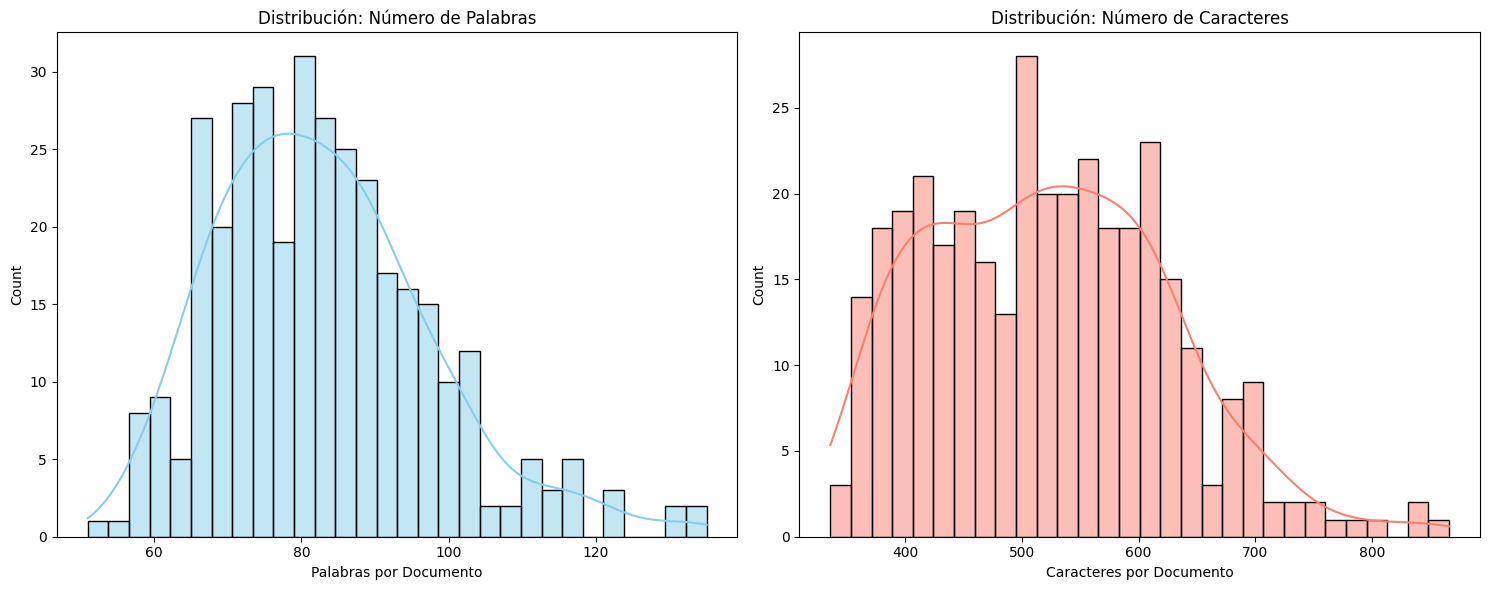

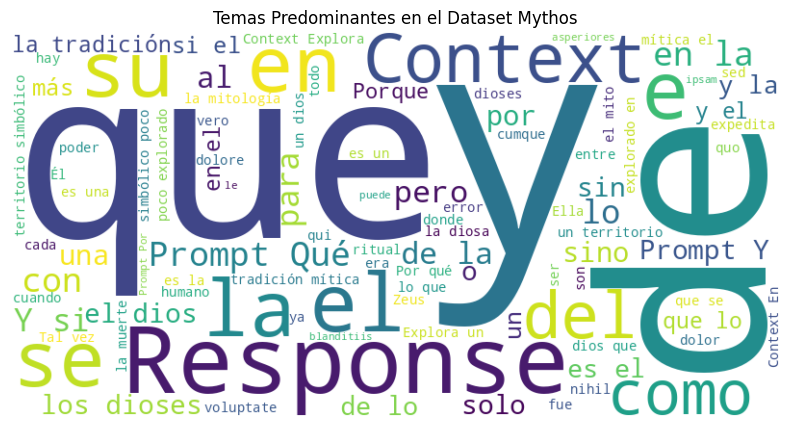

------------------------------
📊 RESUMEN ESTADÍSTICO
------------------------------
Total de registros: 347
Promedio de palabras: 82.88
Máximo de palabras: 135
Documentos con posibles nulos: 0
------------------------------


In [ ]:
# 1. Convertir el dataset (ya con la columna 'document') a Pandas
df = dataset_mythos.to_pandas()

# 2. Cálculo de métricas básicas
df['word_count'] = df['document'].apply(lambda x: len(str(x).split()))
df['char_count'] = df['document'].apply(lambda x: len(str(x)))

# --- VISUALIZACIÓN ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histograma de Palabras
sns.histplot(df['word_count'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title("Distribución: Número de Palabras")
axes[0].set_xlabel("Palabras por Documento")

# Histograma de Caracteres
sns.histplot(df['char_count'], bins=30, kde=True, ax=axes[1], color='salmon')
axes[1].set_title("Distribución: Número de Caracteres")
axes[1].set_xlabel("Caracteres por Documento")

plt.tight_layout()
plt.show()

# 3. Nube de Palabras (Frecuencia Semántica)
plt.figure(figsize=(10, 5))
text_combined = " ".join(df['document'].tolist())
wordcloud = WordCloud(width=800, height=400, background_color='white',
                      colormap='viridis', max_words=100).generate(text_combined)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Temas Predominantes en el Dataset Mythos")
plt.show()

# 4. Reporte Estadístico Final
print("-" * 30)
print("📊 RESUMEN ESTADÍSTICO")
print("-" * 30)
print(f"Total de registros: {len(df)}")
print(f"Promedio de palabras: {df['word_count'].mean():.2f}")
print(f"Máximo de palabras: {df['word_count'].max()}")
print(f"Documentos con posibles nulos: {df['document'].isna().sum()}")
print("-" * 30)

Esto indica una longitud relativamente homogénea, adecuada para procesos de embedding sin necesidad inmediata de segmentación (*chunking*).

Adicionalmente, la nube de palabras permite identificar términos predominantes asociados a la estructura del dataset (`Prompt`, `Context`, `Response`) y al dominio temático (mitología).

**Resumen:**
- Total de registros: 347  
- Promedio de palabras: ~82  
- Máximo de palabras: ~135  
- Valores nulos: 0  

En conjunto, el dataset presenta consistencia estructural y calidad suficiente para tareas de recuperación semántica en un entorno RAG.

**Observaciones**

- La longitud promedio de los documentos (~82 palabras) es adecuada para modelos de embedding tipo sentence-transformer, permitiendo representar el contenido sin truncamiento ni necesidad inmediata de segmentación.

- La distribución de longitudes es relativamente homogénea, lo que favorece la estabilidad en la generación de embeddings y reduce sesgos en la similitud semántica.

- El tamaño del dataset (347 registros) es suficiente para pruebas funcionales de un sistema RAG; sin embargo, es limitado para cubrir de forma robusta la variabilidad del dominio, por lo que su uso se restringe a escenarios demostrativos.

- La estructura consolidada (`Prompt + Context + Response`) preserva la coherencia semántica del contenido, aunque puede introducir redundancia léxica que afecte marginalmente la calidad del retrieval.

# Modelos de Lenguaje Grande (LLMs) - Embeddings

Se utiliza LangChain junto con FAISS para la construcción del *document store*, donde los textos son transformados en embeddings y almacenados para su posterior recuperación semántica.

En esta implementación no se aplica segmentación (*chunking*), debido a que los documentos presentan una longitud moderada (~82 palabras en promedio), lo que permite indexarlos como unidades completas sin pérdida significativa de contexto. No obstante, en escenarios con documentos más extensos, el *chunking* resulta necesario para mejorar la granularidad del retrieval.

### Cargando a Ollama

In [ ]:
!if ! type ollama > /dev/null; then sudo apt-get install zstd -y && curl -fsSL https://ollama.com/install.sh | sh; else echo "Ollama ya está instalado."; fi

/bin/bash: line 1: type: ollama: not found
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  zstd
0 upgraded, 1 newly installed, 0 to remove and 42 not upgraded.
Need to get 603 kB of archives.
After this operation, 1,695 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 zstd amd64 1.4.8+dfsg-3build1 [603 kB]
Fetched 603 kB in 1s (1,066 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package zstd.
(Reading database

### Configuración de Ollama

Se instala y configura Ollama como entorno de ejecución local para modelos de lenguaje. Este componente permite ejecutar modelos tipo LLaMA sin depender de servicios externos, facilitando pruebas y despliegues en entornos controlados.

Una vez finalizada la instalación, es necesario iniciar el servicio mediante:

```bash
ollama serve &

In [ ]:
%load_ext colabxterm
%xterm

Launching Xterm...

<IPython.core.display.Javascript object>

Para esta implementación se selecciona el modelo `llama3.2:3b`, una variante compacta que ofrece un balance adecuado entre capacidad de generación y costo computacional. Su tamaño permite ejecutar inferencia local de forma más eficiente, lo que resulta conveniente para pruebas funcionales y entornos con recursos limitados.

In [ ]:
!ollama pull llama3.2:3b

## Integración con LangChain

Se utiliza LangChain como capa de orquestación para la interacción con el modelo de lenguaje, permitiendo estructurar el flujo de generación de respuestas dentro de la arquitectura RAG.

En este caso, se instancia el modelo `llama3.2:3b` a través de `ChatOllama`, lo que habilita su uso mediante una interfaz estandarizada compatible con los componentes de LangChain.

La configuración incluye la validación del modelo al momento de su inicialización (`validate_model_on_init=True`), asegurando que el recurso esté disponible antes de ejecutar consultas.

Se realiza una prueba básica de inferencia para verificar la correcta conexión con el modelo y su capacidad de generación, confirmando que el entorno de ejecución se encuentra operativo.

In [ ]:
llm = ChatOllama(model="llama3.2:3b", validate_model_on_init=True)
llm.invoke("El primer hombre en la luna fue...").content

'...Neil Armstrong. Fue el primer astronauta estadounidense en caminar sobre la superficie lunar durante la misión Apollo 11, que tuvo lugar el 20 de julio de 1969. Después de decir "Estoy aquí", se convirtió en la primera persona en escalar el muro lunar y hacer historia.'

## Construcción del Document Store

Se construye un *document store* utilizando FAISS como motor de indexación vectorial, a través de la integración con LangChain.

Para ello, los documentos del dataset (`document`) son transformados en representaciones vectoriales mediante el modelo de embeddings `intfloat/multilingual-e5-large`, el cual está optimizado para tareas de recuperación semántica.

El flujo implementado es el siguiente:
- Generación de embeddings a partir del corpus textual.
- Creación o carga de un índice FAISS persistente en disco (`./faiss_index`).
- Almacenamiento eficiente de los vectores para consultas posteriores.

En caso de existir un índice previamente construido, este se carga desde disco, evitando reprocesamiento. De lo contrario, se genera un nuevo índice y se guarda localmente.

Finalmente, se configura un *retriever* que permite recuperar los `k=5` documentos más relevantes en función de la similitud semántica frente a una consulta.

Este componente constituye la base del sistema RAG, ya que define la calidad del contexto que será utilizado por el modelo generativo.

In [ ]:
embeddings = HuggingFaceEmbeddings(model_name="intfloat/multilingual-e5-large")
texts = dataset_mythos['document'] # Updated to use the 'document' column from the 'dataset' variable

index_path = './faiss_index'
if os.path.exists(index_path):
    vectorstore = FAISS.load_local(index_path, embeddings, allow_dangerous_deserialization=True)
else:

    vectorstore = FAISS.from_texts(texts, embeddings)
    vectorstore.save_local(index_path)

retriever = vectorstore.as_retriever(search_kwargs={"k": 5})

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/418 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/201 [00:00<?, ?B/s]

## Poniendo a prueba un QA simple
Ahora configuamos un prompt y un RetrievalQA para nuestro caso. Aquí observamos la simpleza para crear la interfaz. Esta es una de las formas de crearla. Esta forma, según la librería está deprecada y podría ser removida en el futuro.

In [ ]:
template = """Utiliza los siguientes fragmentos de contexto
extraídos de fuentes clásicas para responder la pregunta de forma natural y conversacional.

Si no sabes la respuesta, di que no lo sabes. No menciones que se te ha proporcionado un contexto.
Es obligatorio incluir las citas de las fuentes al final de tu respuesta.

Contexto:
{context}

Pregunta: {question}

Respuesta Útil:"""

prompt_mythos = ChatPromptTemplate.from_template(template)

# 2. Construcción de la cadena con LCEL para recuperar fuentes
# Usamos RunnableParallel para que la salida incluya tanto la respuesta como los documentos
setup_and_retrieval = RunnableParallel(
    {"context": retriever, "question": RunnablePassthrough()}
)

chain = setup_and_retrieval | {
    "response": prompt_mythos | llm | StrOutputParser(),
    "docs": lambda x: x["context"]
}

# 3. Ejecución de la consulta sobre mitología
pregunta = "¿Quiénes son los principales dioses del Olimpo?"
resultado = chain.invoke(pregunta)

# 4. Impresión de resultados y fuentes
print(f"RESPUESTA:\n{resultado['response']}\n")
print("FUENTES UTILIZADAS:")

for i, doc in enumerate(resultado["docs"], 1):
    # Intentamos obtener metadatos si los guardaste en el vectorstore
    # Si usaste el proceso de 'document' unificado, el contenido está en page_content
    source_info = doc.metadata.get('source', 'Fuente del Dataset Mythos')
    print(f"- [{i}] {source_info}: {doc.page_content[:100]}...")

RESPUESTA:
En la mitología griega, los principales dioses del Olimpo son hijos de Cronos y Gea. Estos dioses se unen para derrocar a su padre, Urano, y luego a otros Titanes. Entre ellos destacan Zeus, Poseidón, Hades, Hera, Deméter, Atenea, Apolo, Artemisa y Afrodita.

"En el Olimpo vivían los dioses: Zeus, Poseidón, Hades, Hera, Deméter, Atenea, Ares, Afrodita y Hermes, además de otros muchos." - "La Teogonía de Hesíodo"

También es importante mencionar a Dioniso, quien también se considera uno de los dioses principales del Olimpo.

Es interesante destacar que la mitología griega no siempre fue homogénea en cuanto a la inclusión de ciertos dioses.

FUENTES UTILIZADAS:
- [1] Fuente del Dataset Mythos: Prompt: ¿Quiénes fueron los primeros dioses según la mitología griega?
Context: En la Teogonía de He...
- [2] Fuente del Dataset Mythos: Prompt: ¿Qué son los Titanes y qué papel tienen en la mitología griega?
Context: Según Hesíodo, los ...
- [3] Fuente del Dataset Mythos: Prompt: ¿Y si 

Ahora, si hacemos una nueva pregunta observamos que las referencias cambian. Es buena señal de que nuestro RAG está funcionando como se debe.

In [ ]:
# 1. Definimos la pregunta sobre mitología
pregunta_mitologica = "¿Quién es el dios del agua?"

# 2. Ejecutamos la cadena (usando la estructura LCEL que armamos anteriormente)
# Nota: Si tu cadena espera un diccionario, asegúrate de que la clave coincida con tu Prompt
result = chain.invoke(pregunta_mitologica)

# 3. Formateamos y mostramos la respuesta
# Si 'rag_chain' termina en un StrOutputParser, 'result' ya es un string directo.
print("--- Respuesta del Experto en Mitología ---")
print(result)
for i, doc in enumerate(result["docs"], 1):
    # Intentamos obtener metadatos si los guardaste en el vectorstore
    # Si usaste el proceso de 'document' unificado, el contenido está en page_content
    source_info = doc.metadata.get('source', 'Fuente del Dataset Mythos')
    print(f"- [{i}] {source_info}: {doc.page_content[:100]}...")

--- Respuesta del Experto en Mitología ---
{'response': 'En la mitología griega, Poseidón es considerado el dios del mar y de las aguas profundas. Sin embargo, también se le asocia con la actividad sísmica y el terremoto.\n\n"El agua no se posee, ni se embotella. Lo sagrado en su elemento no puede domesticarse." (Ovidio)\n\nAdemás, en otras mitologías como la mexica, Tlaloc es considerado el dios del agua y de las lluvias.\n\n"Tlaloc daba lluvia... y también diluvios." (Mitología mexica)\n\nEn cuanto al dios sumerio, Enki se le asocia con el agua y la sabiduría.\n\n"Enki da forma a los humanos con arcilla y les otorga conciencia." (Mitología sumeria)\n\nEn resumen, aunque no hay un dios único asociado exclusivamente con el agua en todas las mitologías, Poseidón, Tlaloc y Enki son algunas de las figuras más destacadas en la mitología relacionada con el agua.\n\nCitaciones:\n\n* Ovidio: "Metamorfosis" (libro III, capítulo IV)\n* Mitología mexica: "Popol Vuh"\n* Mitología sumeria: "Epic o

## Cadena conversacional con memoria

Se implementa una cadena RAG con soporte de historial conversacional utilizando LCEL (LangChain Expression Language). El flujo se compone de tres etapas:

1. **Reformulación de la pregunta (Condense):**  
   Se transforma la consulta del usuario en una pregunta independiente (*standalone question*) utilizando el historial de conversación (`chat_history`). Esto evita ambigüedades en consultas de seguimiento.

2. **Recuperación de contexto (Retrieve):**  
   La pregunta reformulada se utiliza para consultar el *retriever*, obteniendo los documentos más relevantes desde el índice FAISS.

3. **Generación de respuesta (Generate):**  
   El modelo LLM genera la respuesta final utilizando el contexto recuperado y el historial conversacional.

El flujo se implementa mediante composición funcional en LCEL, encadenando transformaciones (`RunnablePassthrough`, `RunnableBranch`) y prompts (`ChatPromptTemplate`).

El historial de conversación se gestiona manualmente, almacenando pares de mensajes (`HumanMessage`, `AIMessage`) que se inyectan en cada nueva interacción.

Este enfoque permite mantener coherencia contextual entre múltiples turnos, mejorando la calidad de las respuestas en escenarios conversacionales.

In [ ]:
# 1. Template para reformular la pregunta (Condensación)
condense_system_prompt = (
    "Dado el siguiente historial de conversación y una pregunta de seguimiento, "
    "reformúla la pregunta para que sea independiente y comprensible por sí misma "
    "en el contexto de la mitología griega. NO respondas la pregunta, solo reformúlala."
)

condense_prompt = ChatPromptTemplate.from_messages([
    ("system", condense_system_prompt),
    ("placeholder", "{chat_history}"),
    ("human", "{input}"),
])

# 2. Cadena para crear una pregunta independiente
# Si no hay historial, pasa la pregunta original. Si hay, la reformula.
query_transformer = RunnableBranch(
    (
        lambda x: not x.get("chat_history"),
        (lambda x: x["input"])
    ),
    condense_prompt | llm | StrOutputParser(),
)

# 3. Template para la respuesta final (QA)
system_prompt = (
    "Eres un erudito en mitología clásica. Responde de forma natural y conversacional "
    "usando el contexto proporcionado. No menciones que tienes documentos externos. "
    "Si no conoces la respuesta basada en el contexto, admítelo.\n\n"
    "Contexto:\n{context}"
)

qa_prompt = ChatPromptTemplate.from_messages([
    ("system", system_prompt),
    ("placeholder", "{chat_history}"),
    ("human", "{input}"),
])

# 4. Construcción de la Cadena RAG con Memoria (LCEL)
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

# Esta cadena: 1. Reformula -> 2. Recupera -> 3. Responde
full_chain = (
    RunnablePassthrough.assign(
        standalone_question=query_transformer
    )
    | RunnablePassthrough.assign(
        context=lambda x: format_docs(retriever.invoke(x["standalone_question"])) # FIXED: Explicitly pass standalone_question to retriever
    )
    | qa_prompt
    | llm
    | StrOutputParser()
)

# 5. Ejecución con gestión de historial
chat_history = []  # Inicialmente vacío

# Pregunta sobre mitología
pregunta_usuario = "¿Quién es Zeus y cuál es su arma principal?"

response = full_chain.invoke({
    "input": pregunta_usuario,
    "chat_history": chat_history,
})

# Actualización manual del historial (Vital para la siguiente pregunta)
chat_history.extend([
    HumanMessage(content=pregunta_usuario),
    AIMessage(content=response)
])

print(f"Respuesta: {response}")

# Siguiente pregunta (para probar la memoria)
pregunta_seguimiento = "¿Quiénes eran sus hermanos?"
response_2 = full_chain.invoke({
    "input": pregunta_seguimiento,
    "chat_history": chat_history,
})

print(f"\nRespuesta a seguimiento: {response_2}")

Respuesta: Zeus es uno de los dioses más importantes en la mitología griega, conocido como el rey del Olimpo y legislador supremo de los dioses. Es el hijo de Cronos y Rhea, y se convierte en un poderoso líder de la sociedad después de derrocar a su padre. Su característica principal es su dominio sobre el cielo y el trueno.

En cuanto a su arma principal, Zeus suele representar con un rayo o una lluvia de truenos. No tiene un arma tradicional como espada o hacha, sino que su poder surge del trueno y la electricidad. Es capaz de controlar los elementos y ejercer su voluntad a través de sus poderosos rayos divinos.

Sin embargo, en algunos mitos también se le representa con una lanza, pero es más conocido por su habilidad para arrojar el trueno como arma.

Respuesta a seguimiento: Zeus tenía varios hermanos que fueron alimentados y protegidos por su madre, Rhea. Después de que Cronos devoró a la mayoría de sus hijos, Zeus fue salvado por su madre y se escondió en una cueva en Creta.

En

In [ ]:
response

{'input': 'qué es el feng shui?',
 'chat_history': [HumanMessage(content='qué es el feng shui?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='El Feng Shui es una tradición china que se enfoca en el equilibrio y la armonía de los elementos naturales, como el aire, el agua, la tierra y el fuego, con el objetivo de crear un ambiente que promueva el bienestar físico, mental y espiritual.\n\nEl término "Feng Shui" se compone de dos palabras chinas: "feng", que significa "vento" o "corriente", y "shui", que significa "agua". En realidad, el Feng Shui no se enfoca únicamente en el aire ni en el agua, sino que considera todos los elementos naturales y cómo interactúan entre sí.\n\nLa práctica del Feng Shui se basa en la creencia de que las energías (o "chi" en chino) fluyen a través del espacio y que pueden influir en nuestras vidas. Los practicantes del Feng Shui buscan identificar y manipular estas energías para crear un ambiente que promueva el bienestar y la prosperida

# Lanzando la interfáz de usuario del ChatBot

Finalmente, utilizarémos gradio nuevamente para construir la interfáz conversacional.

Nótese el manejo que le damos al historial de la conversación. Tenémos dos:

1. `lc_history`: Exclusivo al historial de LangChain, contiene estructuras propias de LangChain
2. `chat_history`: Es el historial de la interfaz de gradio, es mas simple y no debe mezclarse con el otro.

In [ ]:
from langchain_ollama import ChatOllama

test_llm = ChatOllama(model="llama3.2:3b")
try:
    res = test_llm.invoke("¿Estás ahí?")
    print("✅ Conexión exitosa:", res.content)
except Exception as e:
    print("❌ Error persistente:", e)

✅ Conexión exitosa: ¡Sí! Estoy aquí y listo para ayudarte. ¿En qué puedo ayudarte hoy?


In [ ]:
# Usaremos la 'full_chain' (LCEL) que definimos en el paso anterior
# lc_history almacenará los objetos de mensaje para la lógica de la IA
lc_history = []

def respond(question, chat_history):
    # 1. Invocamos la cadena LCEL
    reply_text = full_chain.invoke({
        "input": question,
        "chat_history": lc_history
    })

    # 2. Actualizamos el historial interno para LangChain (Objetos)
    lc_history.append(HumanMessage(content=question))
    lc_history.append(AIMessage(content=reply_text))

    # 3. ACTUALIZACIÓN PARA GRADIO (Nuevo formato de Mensajes)
    # En lugar de tuplas, añadimos diccionarios con 'role' y 'content'
    chat_history.append({"role": "user", "content": question})
    chat_history.append({"role": "assistant", "content": reply_text})

    return "", chat_history

def reset_chat():
    lc_history.clear()
    return [] # Retornamos lista vacía para el chatbot

with gr.Blocks(theme=gr.themes.Soft()) as gr_blocks:
    gr.Markdown("# 🏛️ Mythos AI Tutor")

    # Especificamos type="messages" para mayor seguridad, aunque el formato de diccionarios lo activa
    chatbot = gr.Chatbot(label="Conversación Mitológica")

    with gr.Row():
        msg = gr.Textbox(label="¿Sobre qué quieres conversar?", scale=4)
        clear = gr.Button("🗑️ Limpiar", scale=1)

    msg.submit(respond, [msg, chatbot], [msg, chatbot])
    clear.click(reset_chat, None, chatbot, queue=False)

gr_blocks.launch(share=True, debug=True)

/tmp/ipykernel_9345/1575482482.py:27: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as gr_blocks:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://0c8d471cb8c96bce04.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://0c8d471cb8c96bce04.gradio.live


In [ ]:
gr_blocks.close()

Closing server running on port: 7860


## Conclusiones

- LangChain permite abstraer y modularizar la construcción de sistemas basados en LLMs, facilitando la integración de componentes como modelos generativos, embeddings y mecanismos de recuperación dentro de una arquitectura RAG.

- El uso de FAISS como motor de indexación vectorial, junto con embeddings preentrenados, permite implementar mecanismos de recuperación semántica eficientes sin necesidad de desarrollar soluciones desde cero.

- La calidad del sistema no depende únicamente del modelo LLM, sino principalmente de decisiones como la estructura del dataset, la estrategia de embeddings, la configuración del retriever (e.g., valor de *k*) y el manejo del contexto.

- La incorporación de memoria conversacional mediante reformulación de preguntas mejora la coherencia en interacciones multi-turno, aunque introduce complejidad adicional y posibles fuentes de error si no se controla adecuadamente.

- A pesar de la simplicidad de implementación, el enfoque presentado corresponde a un entorno demostrativo. Para escenarios reales, es necesario incorporar validación del retrieval, optimización de parámetros y manejo adecuado de la memoria para garantizar robustez y escalabilidad.
